# TimeGAN Model Training for EUR/USD Forex Data
**Optimized for Google Colab with A100 GPU**

This notebook trains a TimeGAN model on preprocessed forex data to generate synthetic time-series sequences.
The model will learn temporal patterns and generate 50-100 future candlesticks.

---

## 1. Environment Setup & GPU Configuration

In [4]:
# Install required packages
!pip install -q tensorflow==2.19.0
!pip install -q numpy pandas matplotlib seaborn scikit-learn
!pip install -q tqdm

In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure TensorFlow for A100 GPU optimization
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Enable mixed precision training for A100
policy = tf.keras.mixed_precision.Policy('mixed_float16')
tf.keras.mixed_precision.set_global_policy(policy)
print('Compute dtype: %s' % policy.compute_dtype)
print('Variable dtype: %s' % policy.variable_dtype)

# GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU Memory growth enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(e)

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Compute dtype: float16
Variable dtype: float32
GPU Memory growth enabled for 1 GPU(s)


## 2. Upload and Load Data

In [6]:
from google.colab import files

# Upload your CSV file
print("Please upload your timegan_ready_strategy_6.csv file:")
uploaded = files.upload()

# Get the filename
filename = list(uploaded.keys())[0]
print(f"\nFile '{filename}' uploaded successfully!")

Please upload your timegan_ready_strategy_6.csv file:


Saving timegan_ready_strategy_6.csv to timegan_ready_strategy_6.csv

File 'timegan_ready_strategy_6.csv' uploaded successfully!


In [7]:
# Load the data
df = pd.read_csv(filename)

print(f"Data shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
display(df.head())

print(f"\nData statistics:")
display(df.describe())

print(f"\nMissing values:")
print(df.isnull().sum())

Data shape: (100608, 16)

Columns: ['time', 'open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume', 'log_ret_open', 'log_ret_high', 'log_ret_low', 'log_ret_close', 'log_ret_open_norm', 'log_ret_high_norm', 'log_ret_low_norm', 'log_ret_close_norm']

First few rows:


,time,open,high,low,close,tick_volume,spread,real_volume,log_ret_open,log_ret_high,log_ret_low,log_ret_close,log_ret_open_norm,log_ret_high_norm,log_ret_low_norm,log_ret_close_norm
0,2009-10-16 01:00:00,1.49390,1.49564,1.49314,1.49527,1421.0,16.0,0.0,0.000228,0.001084,-0.000208,0.000910,0.072245,0.354918,-0.067218,0.288329
1,2009-10-16 02:00:00,1.49524,1.49644,1.49462,1.49641,2180.0,16.0,0.0,0.000897,0.000535,0.000991,0.000762,0.284570,0.175126,0.320788,0.241486
2,2009-10-16 03:00:00,1.49642,1.49651,1.49479,1.49548,1523.0,16.0,0.0,0.000789,0.000047,0.000114,-0.000622,0.250381,0.015319,0.036827,-0.196988
3,2009-10-16 04:00:00,1.49543,1.49637,1.49350,1.49395,1659.0,16.0,0.0,-0.000662,-0.000094,-0.000863,-0.001024,-0.210052,-0.030639,-0.279556,-0.324343
4,2009-10-16 05:00:00,1.49397,1.49448,1.49309,1.49316,1551.0,15.0,0.0,-0.000977,-0.001264,-0.000275,-0.000529,-0.310027,-0.413906,-0.088902,-0.167601



Data statistics:


,open,high,low,close,tick_volume,spread,real_volume,log_ret_open,log_ret_high,log_ret_low,log_ret_close,log_ret_open_norm,log_ret_high_norm,log_ret_low_norm,log_ret_close_norm
count,100608.000000,100608.000000,100608.000000,100608.000000,100608.000000,100608.000000,1.006080e+05,1.006080e+05,100608.000000,1.006080e+05,100608.000000,100608.000000,100608.000000,100608.000000,100608.000000
mean,1.189741,1.190598,1.188899,1.189741,3247.877674,4.670543,8.385074e+08,-3.322740e-07,-0.000002,6.309230e-07,-0.000001,-0.000144,-0.002358,0.001323,-0.000527
std,0.116041,0.116162,0.115910,0.116035,2669.297687,4.628084,2.884826e+09,1.080153e-03,0.001010,1.000065e-03,0.001079,0.304177,0.287251,0.284434,0.303272
min,0.953920,0.955920,0.953570,0.953910,1.000000,0.000000,0.000000e+00,-2.047982e-02,-0.018432,-1.514466e-02,-0.020382,-1.000000,-1.000000,-1.000000,-1.000000
25%,1.098098,1.098850,1.097350,1.098100,1425.000000,1.000000,0.000000e+00,-4.357103e-04,-0.000377,-3.522727e-04,-0.000434,-0.138293,-0.123565,-0.114065,-0.137439
50%,1.157620,1.158370,1.156940,1.157630,2494.000000,4.000000,0.000000e+00,0.000000e+00,-0.000020,2.297407e-05,0.000000,0.000000,-0.006536,0.007439,0.000000
75%,1.290615,1.291780,1.289640,1.290685,4237.000000,8.000000,0.000000e+00,4.395137e-04,0.000347,3.837808e-04,0.000436,0.139500,0.113642,0.124267,0.138101
max,1.514210,1.514370,1.513190,1.514250,66526.000000,122.000000,3.295386e+10,1.727875e-02,0.020686,1.926104e-02,0.017249,1.000000,1.000000,1.000000,1.000000



Missing values:
time                  0
open                  0
high                  0
low                   0
close                 0
tick_volume           0
spread                0
real_volume           0
log_ret_open          0
log_ret_high          0
log_ret_low           0
log_ret_close         0
log_ret_open_norm     0
log_ret_high_norm     0
log_ret_low_norm      0
log_ret_close_norm    0
dtype: int64


## 3. Data Preparation

Feature data shape: (100608, 4)
Feature range - Min: -1.0000, Max: 1.0000
Number of features: 4


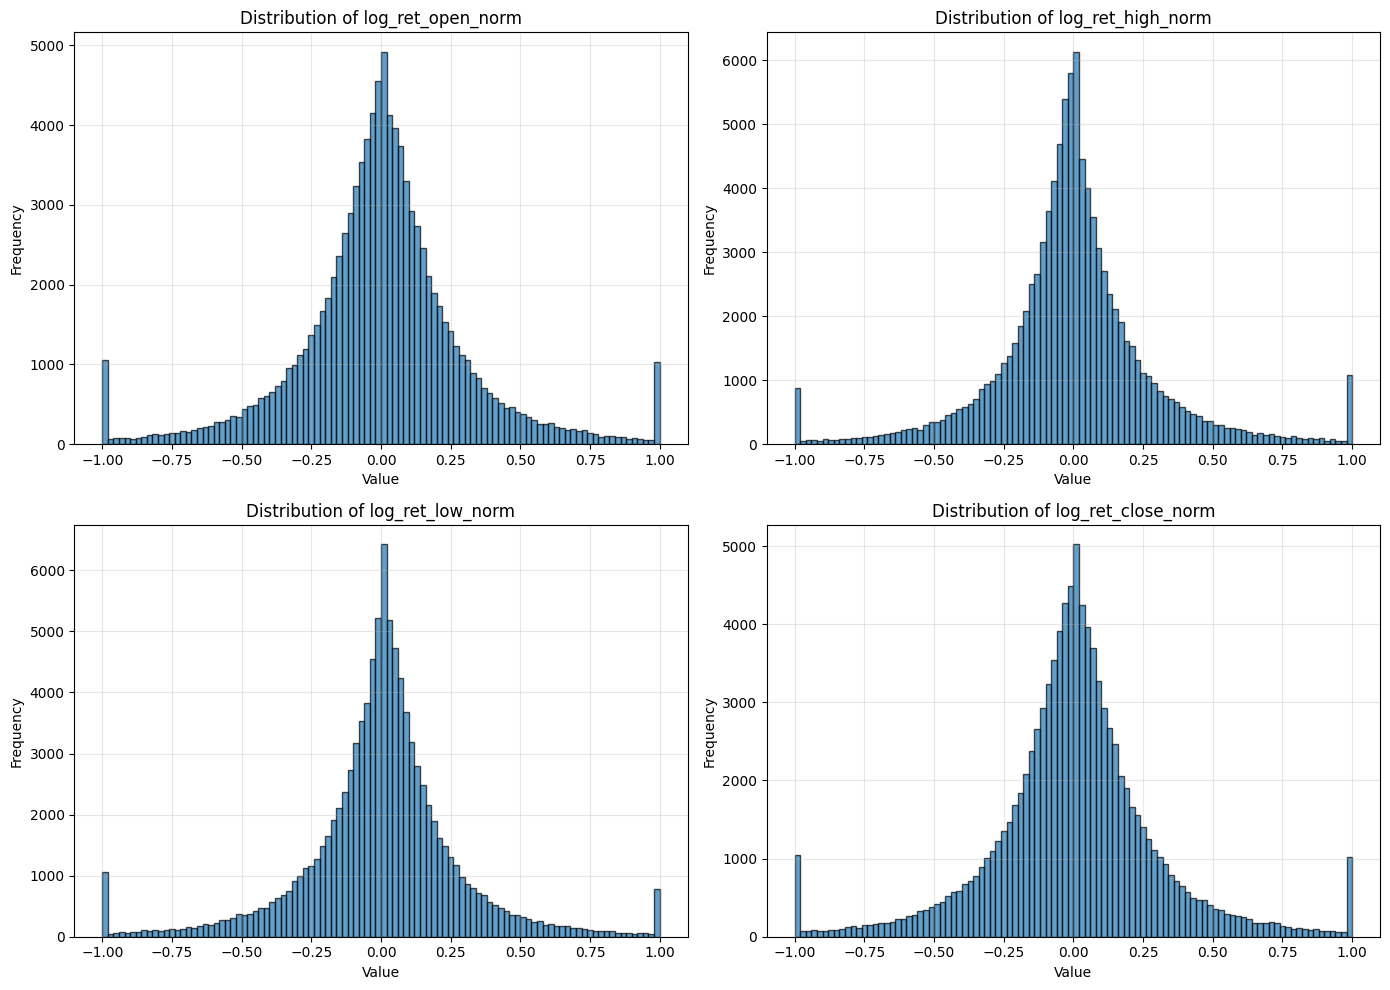

In [8]:
# Select features for training (normalized log returns)
# These are already normalized to [0, 1] range
feature_columns = [
    'log_ret_open_norm',
    'log_ret_high_norm',
    'log_ret_low_norm',
    'log_ret_close_norm'
]

# Extract features
data = df[feature_columns].values

print(f"Feature data shape: {data.shape}")
print(f"Feature range - Min: {data.min():.4f}, Max: {data.max():.4f}")
print(f"Number of features: {len(feature_columns)}")

# Visualize feature distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(feature_columns):
    axes[i].hist(df[col], bins=100, alpha=0.7, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Hyperparameters
SEQ_LENGTH = 24  # Sequence length (24 hours for hourly data)
BATCH_SIZE = 128  # Optimized for A100
NUM_FEATURES = len(feature_columns)

print(f"Sequence Length: {SEQ_LENGTH}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Number of Features: {NUM_FEATURES}")

Sequence Length: 24
Batch Size: 128
Number of Features: 4


In [10]:
def create_sequences(data, seq_length):
    """
    Create overlapping sequences from time series data.

    Args:
        data: numpy array of shape (n_samples, n_features)
        seq_length: length of each sequence

    Returns:
        numpy array of shape (n_sequences, seq_length, n_features)
    """
    sequences = []
    for i in range(len(data) - seq_length + 1):
        sequences.append(data[i:i + seq_length])
    return np.array(sequences)

# Create sequences
sequences = create_sequences(data, SEQ_LENGTH)
print(f"Total sequences created: {len(sequences)}")
print(f"Sequences shape: {sequences.shape}")

# Split into train and validation sets (80-20 split)
train_data, val_data = train_test_split(sequences, test_size=0.2, random_state=42, shuffle=True)

print(f"\nTraining sequences: {len(train_data)}")
print(f"Validation sequences: {len(val_data)}")

Total sequences created: 100585
Sequences shape: (100585, 24, 4)

Training sequences: 80468
Validation sequences: 20117


## 4. TimeGAN Model Architecture

In [11]:
# Model hyperparameters
HIDDEN_DIM = 128  # Hidden dimension for RNN layers
NUM_LAYERS = 3  # Number of GRU layers
Z_DIM = 64  # Random noise dimension
LEARNING_RATE = 1e-4

print(f"Hidden Dimension: {HIDDEN_DIM}")
print(f"Number of Layers: {NUM_LAYERS}")
print(f"Noise Dimension: {Z_DIM}")
print(f"Learning Rate: {LEARNING_RATE}")

Hidden Dimension: 128
Number of Layers: 3
Noise Dimension: 64
Learning Rate: 0.0001


In [12]:
def build_embedder(seq_length, num_features, hidden_dim, num_layers):
    """
    Embedder network: Maps real data to latent space
    """
    inputs = layers.Input(shape=(seq_length, num_features), name='embedder_input')
    x = inputs

    for i in range(num_layers):
        x = layers.GRU(hidden_dim, return_sequences=True, name=f'embedder_gru_{i}')(x)
        x = layers.LayerNormalization(name=f'embedder_ln_{i}')(x)

    outputs = layers.Dense(hidden_dim, activation='sigmoid', name='embedder_output', dtype='float32')(x)

    return Model(inputs=inputs, outputs=outputs, name='embedder')

def build_recovery(seq_length, hidden_dim, num_features, num_layers):
    """
    Recovery network: Maps latent space back to real data
    """
    inputs = layers.Input(shape=(seq_length, hidden_dim), name='recovery_input')
    x = inputs

    for i in range(num_layers):
        x = layers.GRU(hidden_dim, return_sequences=True, name=f'recovery_gru_{i}')(x)
        x = layers.LayerNormalization(name=f'recovery_ln_{i}')(x)

    outputs = layers.Dense(num_features, activation='sigmoid', name='recovery_output', dtype='float32')(x)

    return Model(inputs=inputs, outputs=outputs, name='recovery')

def build_generator(seq_length, z_dim, hidden_dim, num_layers):
    """
    Generator network: Creates synthetic latent representations from noise
    """
    inputs = layers.Input(shape=(seq_length, z_dim), name='generator_input')
    x = inputs

    for i in range(num_layers):
        x = layers.GRU(hidden_dim, return_sequences=True, name=f'generator_gru_{i}')(x)
        x = layers.LayerNormalization(name=f'generator_ln_{i}')(x)

    outputs = layers.Dense(hidden_dim, activation='sigmoid', name='generator_output', dtype='float32')(x)

    return Model(inputs=inputs, outputs=outputs, name='generator')

def build_discriminator(seq_length, hidden_dim, num_layers):
    """
    Discriminator network: Distinguishes real from fake latent representations
    """
    inputs = layers.Input(shape=(seq_length, hidden_dim), name='discriminator_input')
    x = inputs

    for i in range(num_layers):
        x = layers.GRU(hidden_dim, return_sequences=True, name=f'discriminator_gru_{i}')(x)
        x = layers.LayerNormalization(name=f'discriminator_ln_{i}')(x)

    x = layers.Dense(1, activation=None, name='discriminator_dense', dtype='float32')(x)

    return Model(inputs=inputs, outputs=x, name='discriminator')

def build_supervisor(seq_length, hidden_dim, num_layers):
    """
    Supervisor network: Enforces temporal dynamics in latent space
    """
    inputs = layers.Input(shape=(seq_length, hidden_dim), name='supervisor_input')
    x = inputs

    for i in range(num_layers - 1):
        x = layers.GRU(hidden_dim, return_sequences=True, name=f'supervisor_gru_{i}')(x)
        x = layers.LayerNormalization(name=f'supervisor_ln_{i}')(x)

    outputs = layers.Dense(hidden_dim, activation='sigmoid', name='supervisor_output', dtype='float32')(x)

    return Model(inputs=inputs, outputs=outputs, name='supervisor')

# Build all networks
print("Building TimeGAN components...\n")

embedder = build_embedder(SEQ_LENGTH, NUM_FEATURES, HIDDEN_DIM, NUM_LAYERS)
print(f"✓ Embedder: {embedder.count_params():,} parameters")

recovery = build_recovery(SEQ_LENGTH, HIDDEN_DIM, NUM_FEATURES, NUM_LAYERS)
print(f"✓ Recovery: {recovery.count_params():,} parameters")

generator = build_generator(SEQ_LENGTH, Z_DIM, HIDDEN_DIM, NUM_LAYERS)
print(f"✓ Generator: {generator.count_params():,} parameters")

discriminator = build_discriminator(SEQ_LENGTH, HIDDEN_DIM, NUM_LAYERS)
print(f"✓ Discriminator: {discriminator.count_params():,} parameters")

supervisor = build_supervisor(SEQ_LENGTH, HIDDEN_DIM, NUM_LAYERS)
print(f"✓ Supervisor: {supervisor.count_params():,} parameters")

total_params = sum([
    embedder.count_params(),
    recovery.count_params(),
    generator.count_params(),
    discriminator.count_params(),
    supervisor.count_params()
])
print(f"\n📊 Total parameters: {total_params:,}")

Building TimeGAN components...

✓ Embedder: 266,880 parameters
✓ Recovery: 298,500 parameters
✓ Generator: 289,920 parameters
✓ Discriminator: 298,113 parameters
✓ Supervisor: 215,168 parameters

📊 Total parameters: 1,368,581


## 5. Loss Functions and Training

In [13]:
# Optimizers
embedder_optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
recovery_optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
generator_optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
discriminator_optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
supervisor_optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)

# Loss function
mse_loss = keras.losses.MeanSquaredError()
bce_loss = keras.losses.BinaryCrossentropy(from_logits=True)

In [14]:
@tf.function
def train_embedder_step(real_data):
    """
    Training step for embedder and recovery networks (autoencoder)
    """
    with tf.GradientTape() as tape:
        # Forward pass
        h = embedder(real_data, training=True)
        x_tilde = recovery(h, training=True)

        # Reconstruction loss
        e_loss = mse_loss(real_data, x_tilde)

    # Compute gradients and update
    variables = embedder.trainable_variables + recovery.trainable_variables
    gradients = tape.gradient(e_loss, variables)
    embedder_optimizer.apply_gradients(zip(gradients[:len(embedder.trainable_variables)],
                                           embedder.trainable_variables))
    recovery_optimizer.apply_gradients(zip(gradients[len(embedder.trainable_variables):],
                                           recovery.trainable_variables))

    return e_loss

@tf.function
def train_supervisor_step(real_data):
    """
    Training step for supervisor network
    """
    with tf.GradientTape() as tape:
        # Forward pass
        h = embedder(real_data, training=False)
        h_supervised = supervisor(h, training=True)

        # Supervised loss (predict next step in latent space)
        s_loss = mse_loss(h[:, 1:, :], h_supervised[:, :-1, :])

    # Compute gradients and update
    gradients = tape.gradient(s_loss, supervisor.trainable_variables)
    supervisor_optimizer.apply_gradients(zip(gradients, supervisor.trainable_variables))

    return s_loss

@tf.function
def train_generator_discriminator_step(real_data, batch_size):
    """
    Joint training step for generator and discriminator
    """
    # Generate random noise
    z = tf.random.normal(shape=(batch_size, SEQ_LENGTH, Z_DIM))

    # Train Discriminator
    with tf.GradientTape() as tape:
        # Real data
        h_real = embedder(real_data, training=False)
        y_real = discriminator(h_real, training=True)

        # Fake data
        e_hat = generator(z, training=False)
        h_hat = supervisor(e_hat, training=False)
        y_fake = discriminator(h_hat, training=True)

        # Discriminator loss
        d_loss_real = bce_loss(tf.ones_like(y_real), y_real)
        d_loss_fake = bce_loss(tf.zeros_like(y_fake), y_fake)
        d_loss = d_loss_real + d_loss_fake

    # Update discriminator
    d_gradients = tape.gradient(d_loss, discriminator.trainable_variables)
    discriminator_optimizer.apply_gradients(zip(d_gradients, discriminator.trainable_variables))

    # Train Generator
    with tf.GradientTape() as tape:
        # Generate fake data
        e_hat = generator(z, training=True)
        h_hat = supervisor(e_hat, training=False)
        y_fake = discriminator(h_hat, training=False)

        # Moment matching loss
        h_real = embedder(real_data, training=False)
        mean_real = tf.reduce_mean(h_real, axis=0)
        var_real = tf.math.reduce_variance(h_real, axis=0)
        mean_fake = tf.reduce_mean(h_hat, axis=0)
        var_fake = tf.math.reduce_variance(h_hat, axis=0)

        # Generator losses
        g_loss_adversarial = bce_loss(tf.ones_like(y_fake), y_fake)
        g_loss_moment = mse_loss(mean_real, mean_fake) + mse_loss(var_real, var_fake)
        g_loss_supervised = mse_loss(h_hat[:, 1:, :], e_hat[:, :-1, :])

        # Total generator loss
        g_loss = g_loss_adversarial + 100 * tf.sqrt(g_loss_moment) + 100 * g_loss_supervised

    # Update generator and supervisor
    g_variables = generator.trainable_variables + supervisor.trainable_variables
    g_gradients = tape.gradient(g_loss, g_variables)
    generator_optimizer.apply_gradients(zip(g_gradients[:len(generator.trainable_variables)],
                                           generator.trainable_variables))
    supervisor_optimizer.apply_gradients(zip(g_gradients[len(generator.trainable_variables):],
                                            supervisor.trainable_variables))

    return d_loss, g_loss

In [15]:
# Training configuration
EPOCHS_EMBEDDER = 50  # Autoencoder pre-training
EPOCHS_SUPERVISOR = 50  # Supervisor pre-training
EPOCHS_JOINT = 100  # Joint GAN training

print(f"Training Configuration:")
print(f"  Embedder epochs: {EPOCHS_EMBEDDER}")
print(f"  Supervisor epochs: {EPOCHS_SUPERVISOR}")
print(f"  Joint training epochs: {EPOCHS_JOINT}")
print(f"  Total epochs: {EPOCHS_EMBEDDER + EPOCHS_SUPERVISOR + EPOCHS_JOINT}")

Training Configuration:
  Embedder epochs: 50
  Supervisor epochs: 50
  Joint training epochs: 100
  Total epochs: 200


## 6. Phase 1: Embedder Training (Autoencoder)

In [16]:
# Create TensorFlow datasets for efficient training
train_dataset = tf.data.Dataset.from_tensor_slices(train_data)
train_dataset = train_dataset.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices(val_data)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Training dataset batches: {tf.data.experimental.cardinality(train_dataset).numpy()}")
print(f"Validation dataset batches: {tf.data.experimental.cardinality(val_dataset).numpy()}")

Training dataset batches: 629
Validation dataset batches: 158


🚀 Starting Phase 1: Embedder Training (Autoencoder)



Epoch 1/50:   0%|          | 0/629 [00:00<?, ?it/s]

Epoch 2/50:   0%|          | 0/629 [00:00<?, ?it/s]

Epoch 3/50:   0%|          | 0/629 [00:00<?, ?it/s]

Epoch 4/50:   0%|          | 0/629 [00:00<?, ?it/s]

...

Epoch 47/50:   0%|          | 0/629 [00:00<?, ?it/s]

Epoch 48/50:   0%|          | 0/629 [00:00<?, ?it/s]

Epoch 49/50:   0%|          | 0/629 [00:00<?, ?it/s]

Epoch 50/50:   0%|          | 0/629 [00:00<?, ?it/s]

Epoch 50/50 - Loss: 0.043737

✅ Phase 1 complete!


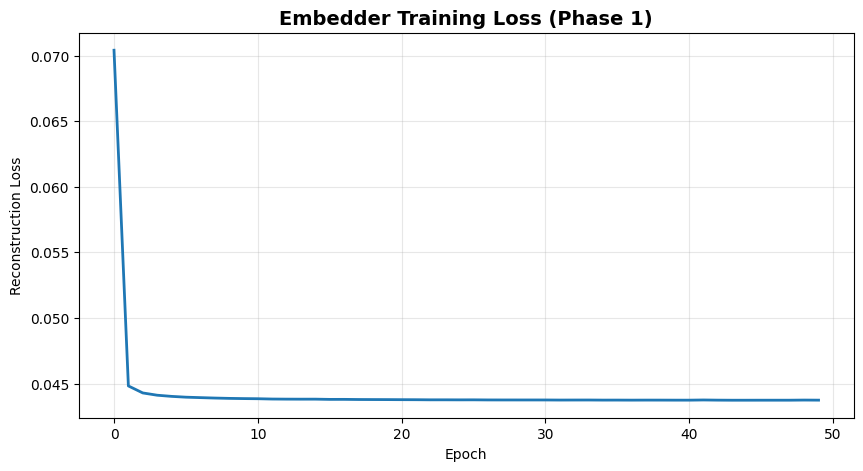

In [17]:
print("🚀 Starting Phase 1: Embedder Training (Autoencoder)\n")

embedder_losses = []

for epoch in range(EPOCHS_EMBEDDER):
    epoch_losses = []

    # Training loop
    for batch in tqdm(train_dataset, desc=f"Epoch {epoch+1}/{EPOCHS_EMBEDDER}", leave=False):
        batch = tf.cast(batch, tf.float32)
        loss = train_embedder_step(batch)
        epoch_losses.append(float(loss))

    avg_loss = np.mean(epoch_losses)
    embedder_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS_EMBEDDER} - Loss: {avg_loss:.6f}")

print("\n✅ Phase 1 complete!")

# Plot embedder training loss
plt.figure(figsize=(10, 5))
plt.plot(embedder_losses, linewidth=2)
plt.title('Embedder Training Loss (Phase 1)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss')
plt.grid(alpha=0.3)
plt.show()

## 7. Phase 2: Supervisor Training

🚀 Starting Phase 2: Supervisor Training



Epoch 1/50:   0%|          | 0/629 [00:00<?, ?it/s]

Epoch 2/50:   0%|          | 0/629 [00:00<?, ?it/s]

Epoch 3/50:   0%|          | 0/629 [00:00<?, ?it/s]

Epoch 4/50:   0%|          | 0/629 [00:00<?, ?it/s]

...

Epoch 47/50:   0%|          | 0/629 [00:00<?, ?it/s]

Epoch 48/50:   0%|          | 0/629 [00:00<?, ?it/s]

Epoch 49/50:   0%|          | 0/629 [00:00<?, ?it/s]

Epoch 50/50:   0%|          | 0/629 [00:00<?, ?it/s]

Epoch 50/50 - Loss: 0.011176

✅ Phase 2 complete!


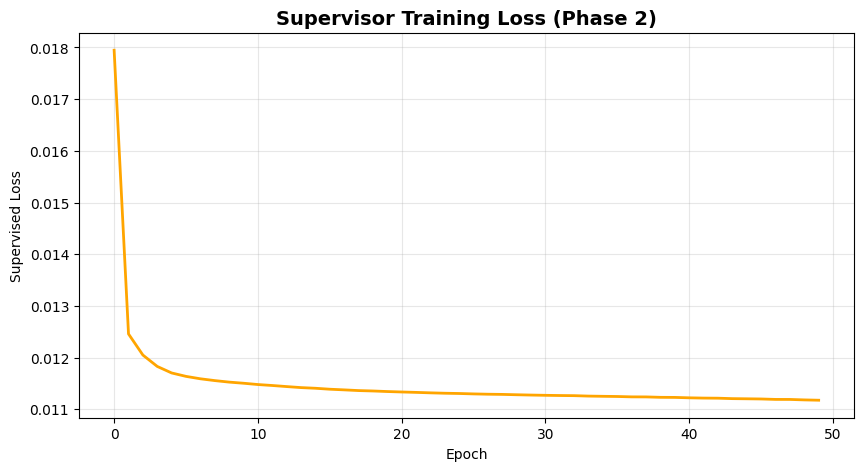

In [18]:
print("🚀 Starting Phase 2: Supervisor Training\n")

supervisor_losses = []

for epoch in range(EPOCHS_SUPERVISOR):
    epoch_losses = []

    # Training loop
    for batch in tqdm(train_dataset, desc=f"Epoch {epoch+1}/{EPOCHS_SUPERVISOR}", leave=False):
        batch = tf.cast(batch, tf.float32)
        loss = train_supervisor_step(batch)
        epoch_losses.append(float(loss))

    avg_loss = np.mean(epoch_losses)
    supervisor_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS_SUPERVISOR} - Loss: {avg_loss:.6f}")

print("\n✅ Phase 2 complete!")

# Plot supervisor training loss
plt.figure(figsize=(10, 5))
plt.plot(supervisor_losses, linewidth=2, color='orange')
plt.title('Supervisor Training Loss (Phase 2)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Supervised Loss')
plt.grid(alpha=0.3)
plt.show()

## 8. Phase 3: Joint GAN Training

🚀 Starting Phase 3: Joint GAN Training



Epoch 1/100:   0%|          | 0/629 [00:00<?, ?it/s]

Epoch 2/100:   0%|          | 0/629 [00:00<?, ?it/s]

Epoch 3/100:   0%|          | 0/629 [00:00<?, ?it/s]

Epoch 4/100:   0%|          | 0/629 [00:00<?, ?it/s]

...

Epoch 97/100:   0%|          | 0/629 [00:00<?, ?it/s]

Epoch 98/100:   0%|          | 0/629 [00:00<?, ?it/s]

Epoch 99/100:   0%|          | 0/629 [00:00<?, ?it/s]

Epoch 100/100:   0%|          | 0/629 [00:00<?, ?it/s]

Epoch 100/100 - D Loss: 1.101691, G Loss: 3.114456

✅ Phase 3 complete!


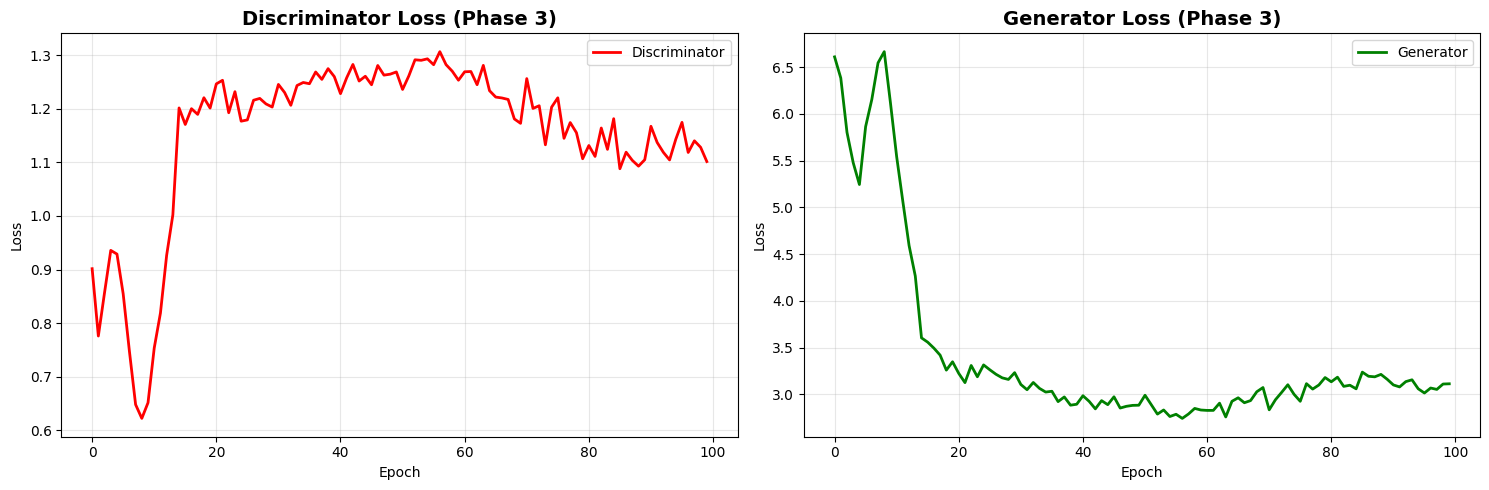

In [19]:
print("🚀 Starting Phase 3: Joint GAN Training\n")

discriminator_losses = []
generator_losses = []

for epoch in range(EPOCHS_JOINT):
    d_losses = []
    g_losses = []

    # Training loop
    for batch in tqdm(train_dataset, desc=f"Epoch {epoch+1}/{EPOCHS_JOINT}", leave=False):
        batch = tf.cast(batch, tf.float32)
        actual_batch_size = tf.shape(batch)[0]

        d_loss, g_loss = train_generator_discriminator_step(batch, actual_batch_size)

        d_losses.append(float(d_loss))
        g_losses.append(float(g_loss))

    avg_d_loss = np.mean(d_losses)
    avg_g_loss = np.mean(g_losses)

    discriminator_losses.append(avg_d_loss)
    generator_losses.append(avg_g_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS_JOINT} - D Loss: {avg_d_loss:.6f}, G Loss: {avg_g_loss:.6f}")

print("\n✅ Phase 3 complete!")

# Plot GAN training losses
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(discriminator_losses, linewidth=2, color='red', label='Discriminator')
ax[0].set_title('Discriminator Loss (Phase 3)', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(generator_losses, linewidth=2, color='green', label='Generator')
ax[1].set_title('Generator Loss (Phase 3)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

## 9. Generate Synthetic Sequences

In [20]:
def generate_sequences(num_sequences=100):
    """
    Generate synthetic time series sequences

    Args:
        num_sequences: Number of sequences to generate

    Returns:
        numpy array of shape (num_sequences, seq_length, num_features)
    """
    # Generate random noise
    z = tf.random.normal(shape=(num_sequences, SEQ_LENGTH, Z_DIM))

    # Generate latent representations
    e_hat = generator(z, training=False)
    h_hat = supervisor(e_hat, training=False)

    # Recover to original space
    x_hat = recovery(h_hat, training=False)

    return x_hat.numpy()

# Generate synthetic candlesticks
NUM_GENERATE = 100  # Generate 100 sequences

print(f"🎨 Generating {NUM_GENERATE} synthetic sequences...")
synthetic_data = generate_sequences(NUM_GENERATE)
print(f"Generated data shape: {synthetic_data.shape}")
print(f"Value range - Min: {synthetic_data.min():.4f}, Max: {synthetic_data.max():.4f}")

🎨 Generating 100 synthetic sequences...
Generated data shape: (100, 24, 4)
Value range - Min: 0.0000, Max: 0.9995


## 10. Visualization & Comparison

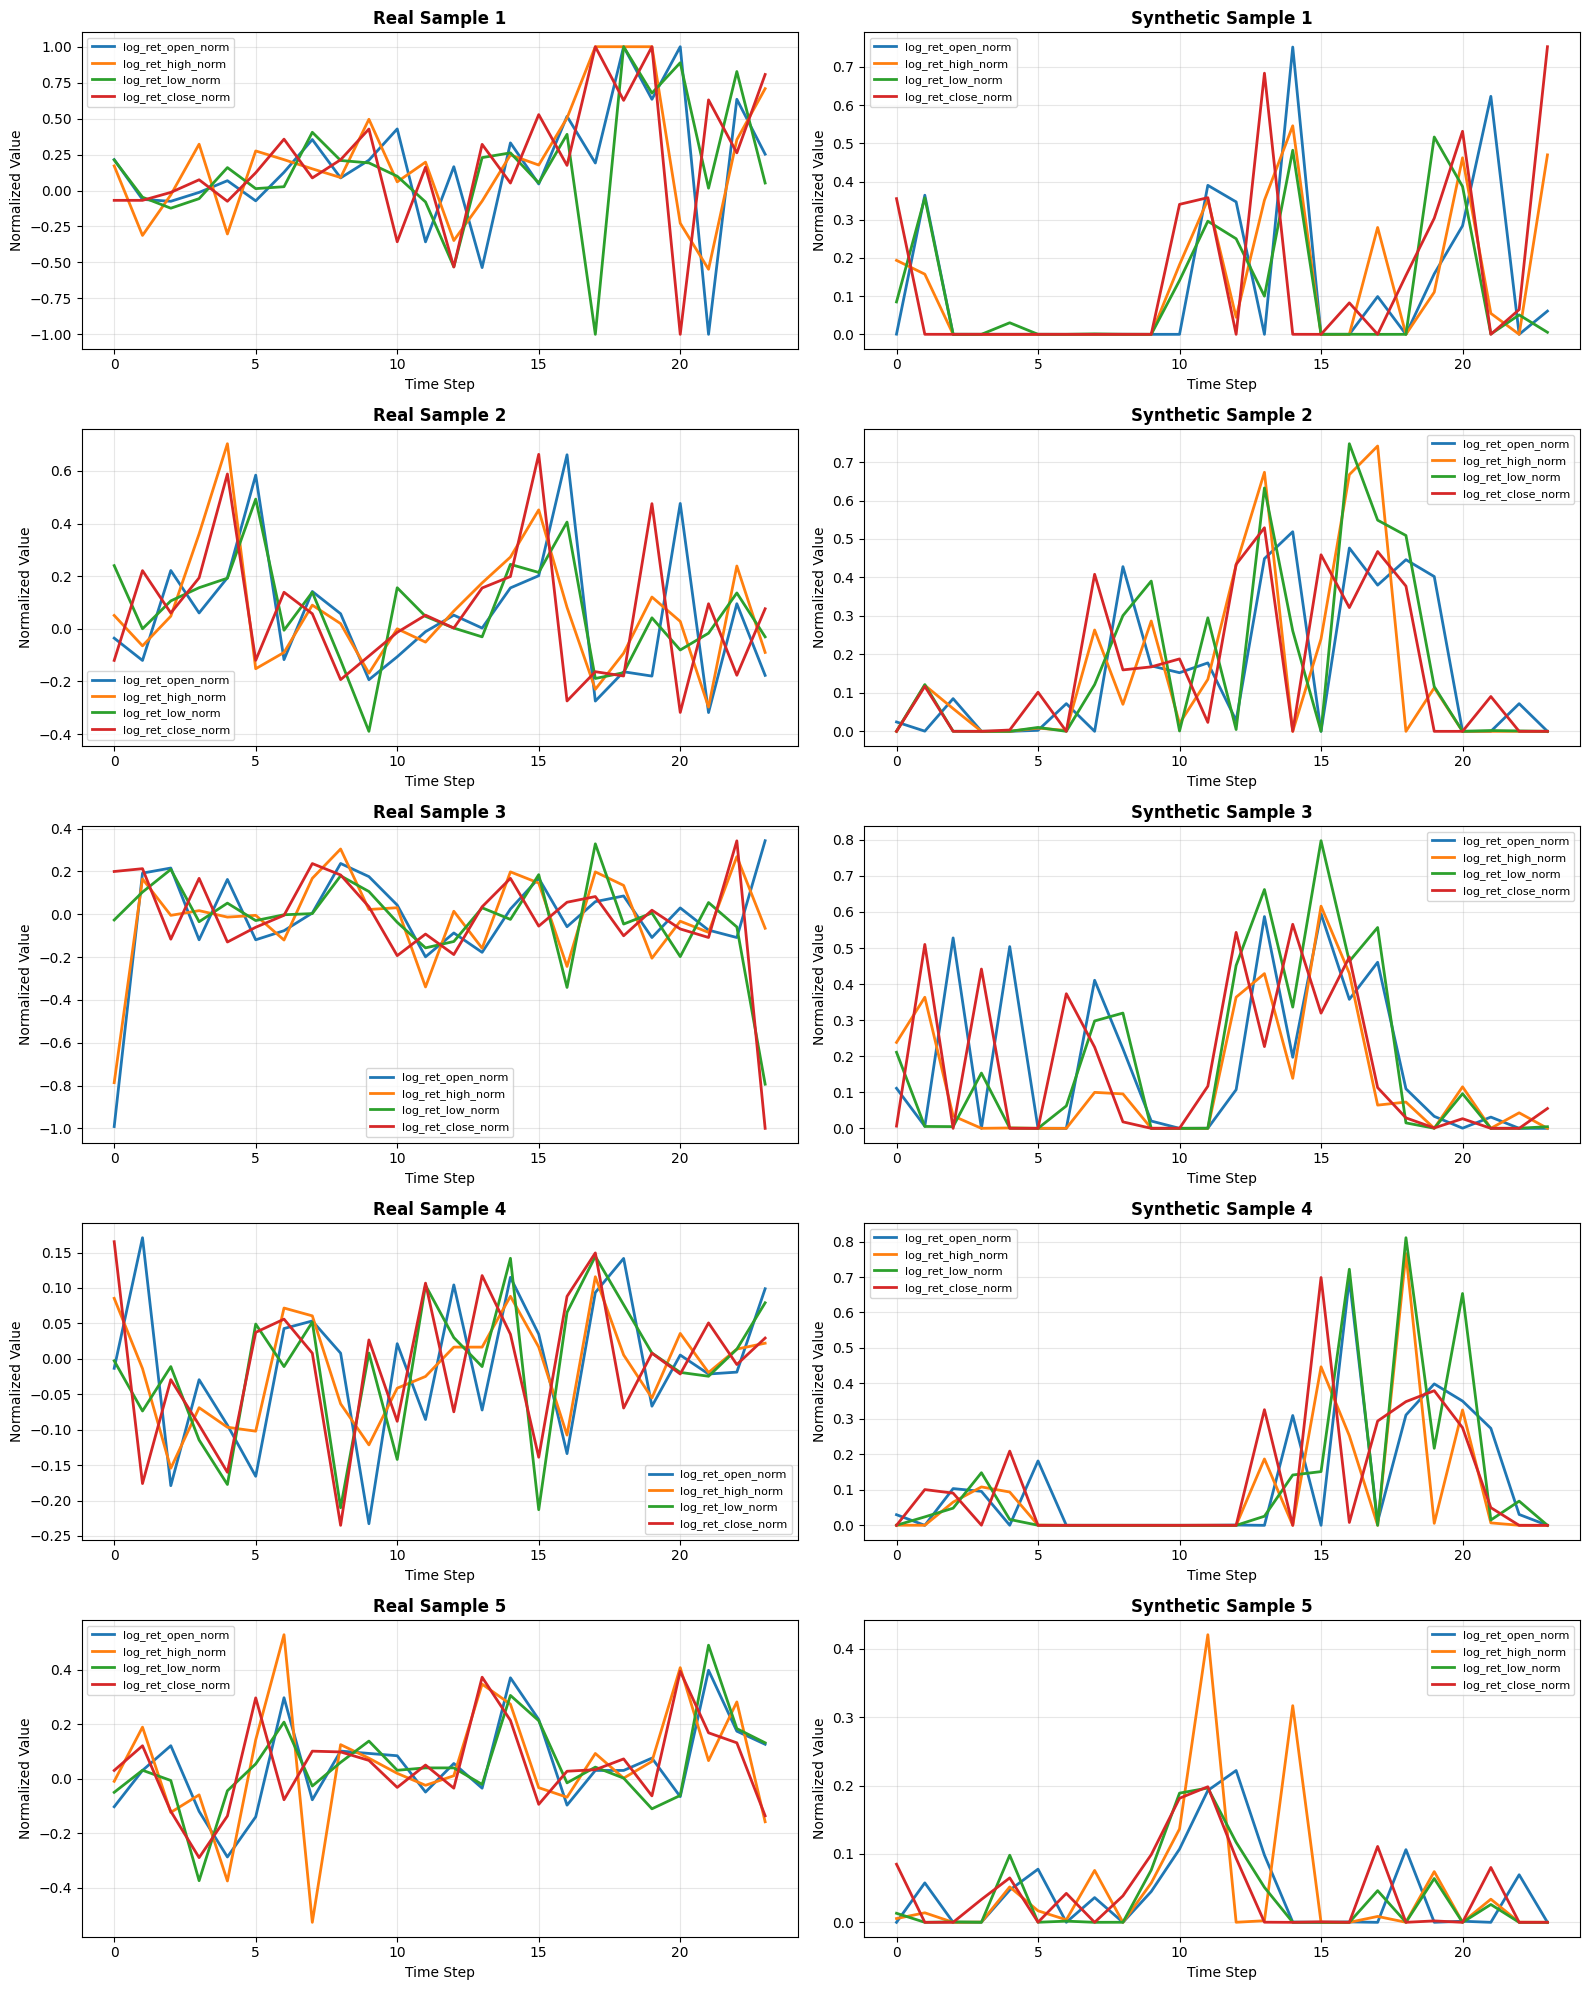

In [21]:
# Select random samples for comparison
real_samples_idx = np.random.choice(len(train_data), 5, replace=False)
real_samples = train_data[real_samples_idx]

synthetic_samples_idx = np.random.choice(len(synthetic_data), 5, replace=False)
synthetic_samples = synthetic_data[synthetic_samples_idx]

# Plot real vs synthetic samples
fig, axes = plt.subplots(5, 2, figsize=(16, 20))

for i in range(5):
    # Real data
    for j, feature in enumerate(feature_columns):
        axes[i, 0].plot(real_samples[i, :, j], label=feature, linewidth=2)
    axes[i, 0].set_title(f'Real Sample {i+1}', fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel('Time Step')
    axes[i, 0].set_ylabel('Normalized Value')
    axes[i, 0].legend(loc='best', fontsize=8)
    axes[i, 0].grid(alpha=0.3)

    # Synthetic data
    for j, feature in enumerate(feature_columns):
        axes[i, 1].plot(synthetic_samples[i, :, j], label=feature, linewidth=2)
    axes[i, 1].set_title(f'Synthetic Sample {i+1}', fontsize=12, fontweight='bold')
    axes[i, 1].set_xlabel('Time Step')
    axes[i, 1].set_ylabel('Normalized Value')
    axes[i, 1].legend(loc='best', fontsize=8)
    axes[i, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

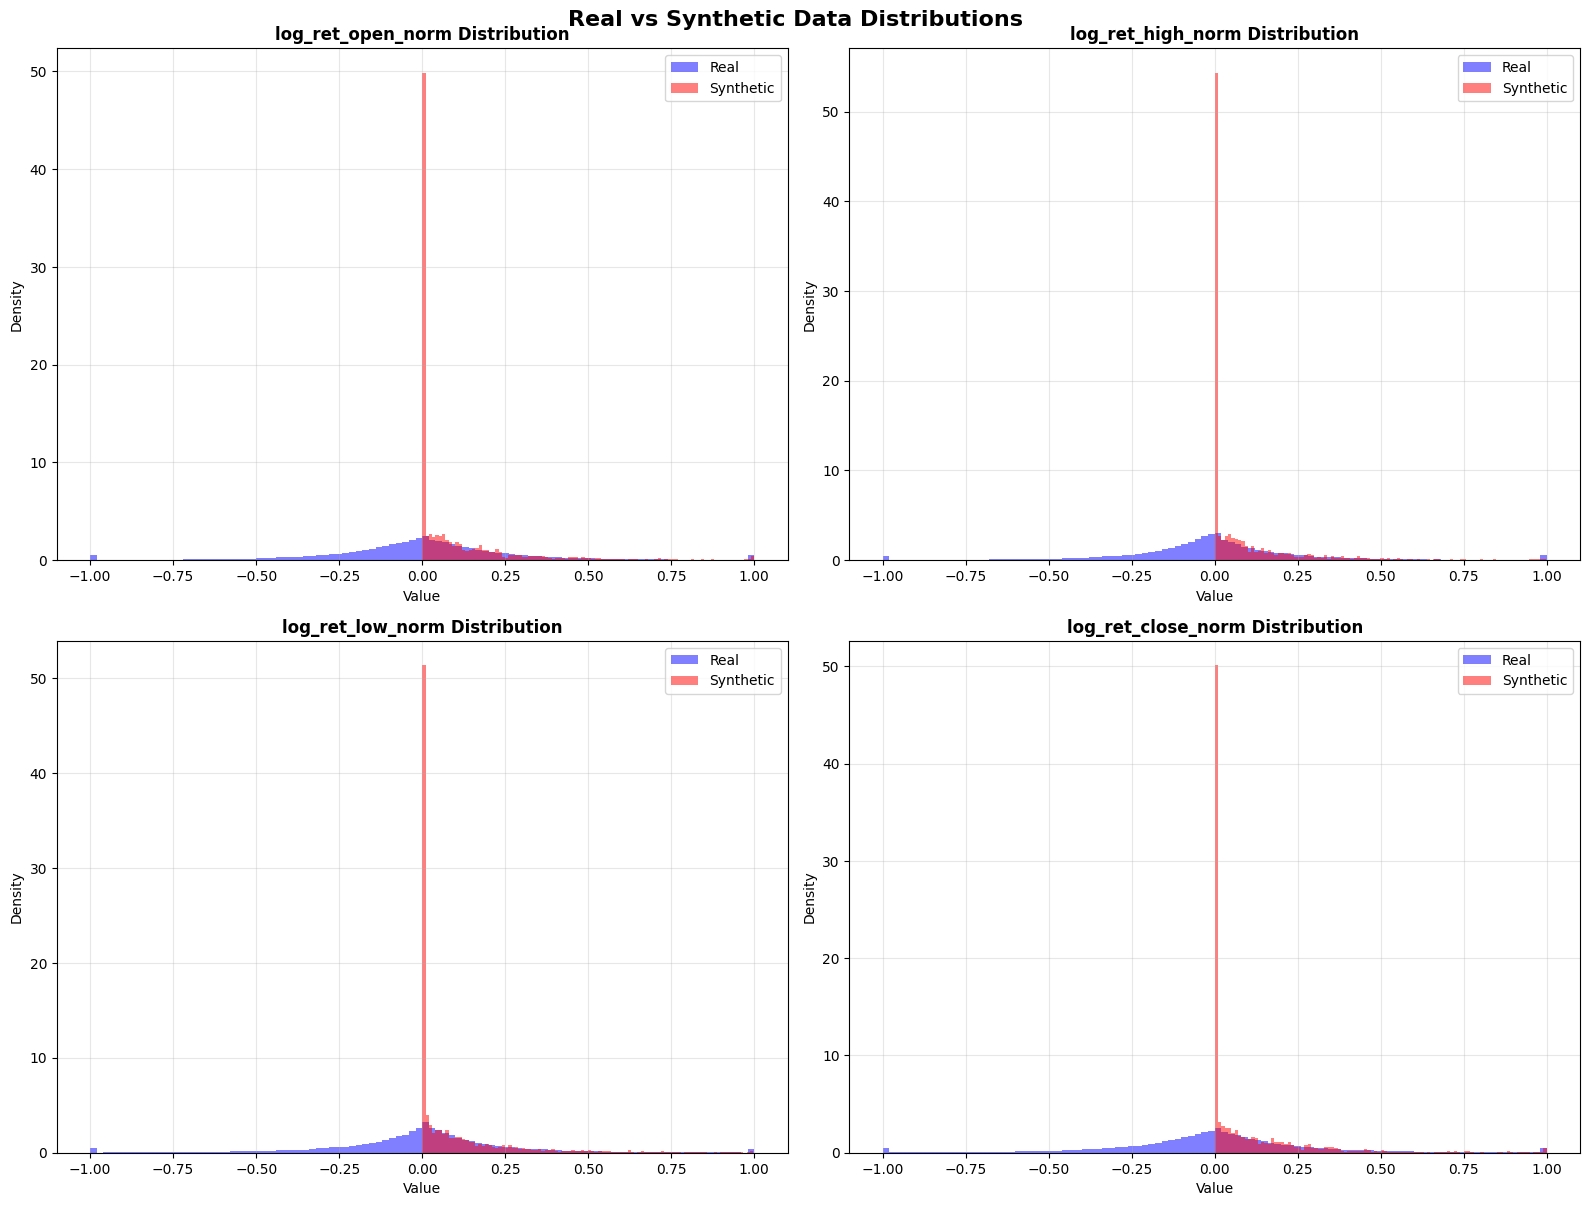

In [22]:
# Distribution comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(feature_columns):
    # Flatten data for distribution comparison
    real_feature = train_data[:, :, i].flatten()
    synthetic_feature = synthetic_data[:, :, i].flatten()

    axes[i].hist(real_feature, bins=100, alpha=0.5, label='Real', color='blue', density=True)
    axes[i].hist(synthetic_feature, bins=100, alpha=0.5, label='Synthetic', color='red', density=True)
    axes[i].set_title(f'{feature} Distribution', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Real vs Synthetic Data Distributions', fontsize=16, fontweight='bold', y=1.001)
plt.show()

## 11. Save Models and Results

In [23]:
# Save all models
print("💾 Saving trained models...\n")

embedder.save('timegan_embedder.h5')
print("✓ Embedder saved")

recovery.save('timegan_recovery.h5')
print("✓ Recovery saved")

generator.save('timegan_generator.h5')
print("✓ Generator saved")

discriminator.save('timegan_discriminator.h5')
print("✓ Discriminator saved")

supervisor.save('timegan_supervisor.h5')
print("✓ Supervisor saved")

print("\n✅ All models saved successfully!")

💾 Saving trained models...

✓ Embedder saved
✓ Recovery saved
✓ Generator saved
✓ Discriminator saved
✓ Supervisor saved

✅ All models saved successfully!


In [26]:
# Save synthetic data to CSV
# Reshape to 2D and create DataFrame
synthetic_flat = synthetic_data.reshape(-1, NUM_FEATURES)
synthetic_df = pd.DataFrame(synthetic_flat, columns=feature_columns)

# Save to CSV
synthetic_df.to_csv('synthetic_data.csv', index=False)
print(f"✅ Synthetic data saved to 'synthetic_data.csv'")
print(f"Shape: {synthetic_df.shape}")

# Also save training history
# Calculate total maximum length for the DataFrame
total_history_epochs = EPOCHS_EMBEDDER + EPOCHS_SUPERVISOR + EPOCHS_JOINT

# Prepare embedder_loss series
embedder_loss_series = embedder_losses + [np.nan] * (total_history_epochs - len(embedder_losses))

# Prepare supervisor_loss series
# It starts after embedder training finishes
supervisor_loss_series = ([np.nan] * EPOCHS_EMBEDDER) + supervisor_losses + \
                         ([np.nan] * (total_history_epochs - EPOCHS_EMBEDDER - len(supervisor_losses)))

# Prepare discriminator_loss series
# It starts after embedder and supervisor training finishes
discriminator_loss_series = ([np.nan] * (EPOCHS_EMBEDDER + EPOCHS_SUPERVISOR)) + discriminator_losses

# Prepare generator_loss series
# It starts after embedder and supervisor training finishes
generator_loss_series = ([np.nan] * (EPOCHS_EMBEDDER + EPOCHS_SUPERVISOR)) + generator_losses

history_df = pd.DataFrame({
    'embedder_loss': embedder_loss_series,
    'supervisor_loss': supervisor_loss_series,
    'discriminator_loss': discriminator_loss_series,
    'generator_loss': generator_loss_series
})

history_df.to_csv('training_history.csv', index=False)
print(f"\n✅ Training history saved to 'training_history.csv'")

✅ Synthetic data saved to 'synthetic_data.csv'
Shape: (2400, 4)

✅ Training history saved to 'training_history.csv'


In [27]:
# Download all files to local machine
from google.colab import files

print("📥 Downloading files...\n")

files.download('timegan_embedder.h5')
files.download('timegan_recovery.h5')
files.download('timegan_generator.h5')
files.download('timegan_discriminator.h5')
files.download('timegan_supervisor.h5')
files.download('synthetic_data.csv')
files.download('training_history.csv')

print("\n✅ All files downloaded!")

📥 Downloading files...



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All files downloaded!


## 12. Generate Future Predictions (50-100 Candles)

In [28]:
# Generate future sequences
NUM_FUTURE = 100  # Number of future candles to generate

print(f"🔮 Generating {NUM_FUTURE} future candlesticks...\n")

# Generate sequences
future_data = generate_sequences(NUM_FUTURE)

# Take only the last timestep from each sequence as the "future" candlestick
future_candles = future_data[:, -1, :]  # Shape: (100, 4)

print(f"Future candles shape: {future_candles.shape}")
print(f"\nFirst 10 future candlesticks (normalized):")
future_df = pd.DataFrame(future_candles, columns=feature_columns)
display(future_df.head(10))

# Save future predictions
future_df.to_csv('future_predictions_100_candles.csv', index=False)
print(f"\n✅ Future predictions saved to 'future_predictions_100_candles.csv'")

# Download
files.download('future_predictions_100_candles.csv')

🔮 Generating 100 future candlesticks...

Future candles shape: (100, 4)

First 10 future candlesticks (normalized):


,log_ret_open_norm,log_ret_high_norm,log_ret_low_norm,log_ret_close_norm
0,0.000123,0.039946,0.000135,0.004106
1,0.042593,0.001780,0.000046,0.001180
2,0.084331,0.047267,0.078627,0.000366
3,0.000032,0.000302,0.000629,0.130650
4,0.171016,0.050427,0.128928,0.096010
5,0.912333,0.618434,0.987951,0.424592
6,0.000128,0.045339,0.042642,0.094453
7,0.116101,0.003006,0.059393,0.000021
8,0.129163,0.034738,0.119532,0.021710
9,0.000046,0.000004,0.000037,0.000017



✅ Future predictions saved to 'future_predictions_100_candles.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

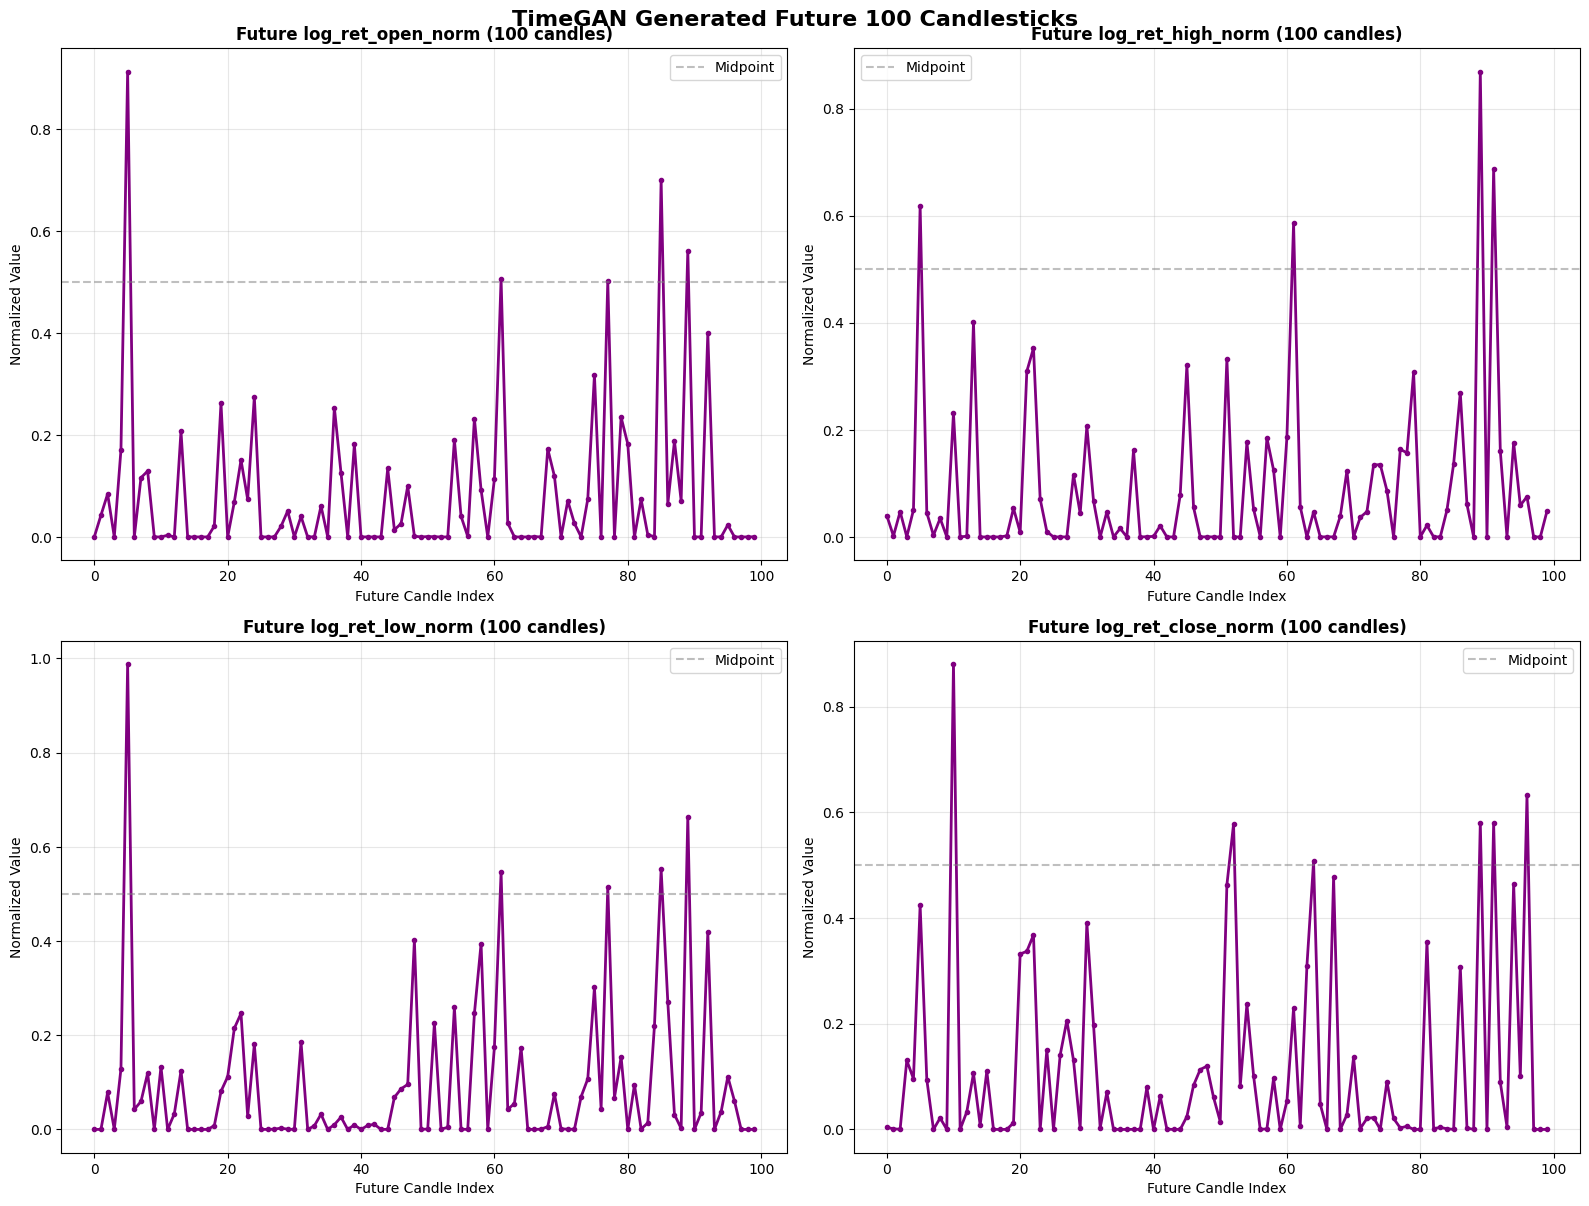

In [29]:
# Visualize future predictions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(feature_columns):
    axes[i].plot(future_candles[:, i], linewidth=2, color='purple', marker='o', markersize=3)
    axes[i].set_title(f'Future {feature} (100 candles)', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Future Candle Index')
    axes[i].set_ylabel('Normalized Value')
    axes[i].grid(alpha=0.3)
    axes[i].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Midpoint')
    axes[i].legend()

plt.tight_layout()
plt.suptitle('TimeGAN Generated Future 100 Candlesticks', fontsize=16, fontweight='bold', y=1.001)
plt.show()

## 13. Summary & Metrics

In [30]:
print("="*70)
print("TimeGAN Training Summary".center(70))
print("="*70)

print(f"\n📊 Model Architecture:")
print(f"  - Sequence Length: {SEQ_LENGTH}")
print(f"  - Features: {NUM_FEATURES}")
print(f"  - Hidden Dimension: {HIDDEN_DIM}")
print(f"  - GRU Layers: {NUM_LAYERS}")
print(f"  - Total Parameters: {total_params:,}")

print(f"\n🏋️ Training Configuration:")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Learning Rate: {LEARNING_RATE}")
print(f"  - Training Samples: {len(train_data):,}")
print(f"  - Validation Samples: {len(val_data):,}")

print(f"\n📈 Training Progress:")
print(f"  - Phase 1 (Embedder): {EPOCHS_EMBEDDER} epochs")
print(f"    Final Loss: {embedder_losses[-1]:.6f}")
print(f"  - Phase 2 (Supervisor): {EPOCHS_SUPERVISOR} epochs")
print(f"    Final Loss: {supervisor_losses[-1]:.6f}")
print(f"  - Phase 3 (GAN): {EPOCHS_JOINT} epochs")
print(f"    Final D Loss: {discriminator_losses[-1]:.6f}")
print(f"    Final G Loss: {generator_losses[-1]:.6f}")

print(f"\n🎨 Generated Data:")
print(f"  - Synthetic Sequences: {NUM_GENERATE}")
print(f"  - Future Predictions: {NUM_FUTURE} candles")

print(f"\n💾 Saved Artifacts:")
print(f"  - timegan_embedder.h5")
print(f"  - timegan_recovery.h5")
print(f"  - timegan_generator.h5")
print(f"  - timegan_discriminator.h5")
print(f"  - timegan_supervisor.h5")
print(f"  - synthetic_data.csv")
print(f"  - future_predictions_100_candles.csv")
print(f"  - training_history.csv")

print("\n" + "="*70)
print("✅ Training Complete!".center(70))
print("="*70)

                       TimeGAN Training Summary                       

📊 Model Architecture:
  - Sequence Length: 24
  - Features: 4
  - Hidden Dimension: 128
  - GRU Layers: 3
  - Total Parameters: 1,368,581

🏋️ Training Configuration:
  - Batch Size: 128
  - Learning Rate: 0.0001
  - Training Samples: 80,468
  - Validation Samples: 20,117

📈 Training Progress:
  - Phase 1 (Embedder): 50 epochs
    Final Loss: 0.043737
  - Phase 2 (Supervisor): 50 epochs
    Final Loss: 0.011176
  - Phase 3 (GAN): 100 epochs
    Final D Loss: 1.101691
    Final G Loss: 3.114456

🎨 Generated Data:
  - Synthetic Sequences: 100
  - Future Predictions: 100 candles

💾 Saved Artifacts:
  - timegan_embedder.h5
  - timegan_recovery.h5
  - timegan_generator.h5
  - timegan_discriminator.h5
  - timegan_supervisor.h5
  - synthetic_data.csv
  - future_predictions_100_candles.csv
  - training_history.csv

                         ✅ Training Complete!                         
